In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import datetime as dt

In [220]:
df = pd.read_csv("sample_sales_data.csv")

# Sales Performance Analysis


In [221]:
df.head()

,Date,Region,Product,Quantity,Unit_Price,Revenue
0,2025-01-05,North,Laptop,5,55000,275000
1,2025-01-07,South,Mouse,20,500,10000
2,2025-01-10,East,Keyboard,15,1200,18000
3,2025-01-12,West,Monitor,8,12000,96000
4,2025-01-15,North,Laptop,3,55000,165000


In [222]:
df.shape

(15, 6)

In [223]:
#What is the total revenue generated?
sum = df['Revenue'].sum()
print(f"The total revenue generated is {sum}")

The total revenue generated is 1181100


In [224]:
#Which product contributes the most revenue?
largest_revenue = df.nlargest(1,columns='Revenue')['Product']
print(largest_revenue)

0    Laptop
Name: Product, dtype: str


In [225]:
#Which product contributes the least revenue?
smallest_revenue = df.nsmallest(1, columns='Revenue')['Product']
print(smallest_revenue)

1    Mouse
Name: Product, dtype: str


In [226]:
#Which region generates the highest revenue?
df.nlargest(1,columns='Revenue')['Region']

0    North
Name: Region, dtype: str

In [227]:
#Which region generates the lowest revenue?
df.nsmallest(1,columns='Revenue')['Region']

1    South
Name: Region, dtype: str

In [228]:
#What percentage of total revenue comes from each region?
(df.groupby('Region')['Revenue'].sum()/sum)*100

Region
East     23.389213
North    44.670223
South    21.632377
West     10.308187
Name: Revenue, dtype: float64

In [229]:
#What percentage of total revenue comes from each product?
df.groupby('Product')['Revenue'].sum()

Product
Keyboard     45600
Laptop      774000
Monitor     303500
Mouse        58000
Name: Revenue, dtype: int64

In [230]:
df

,Date,Region,Product,Quantity,Unit_Price,Revenue
0,2025-01-05,North,Laptop,5,55000,275000
1,2025-01-07,South,Mouse,20,500,10000
2,2025-01-10,East,Keyboard,15,1200,18000
3,2025-01-12,West,Monitor,8,12000,96000
4,2025-01-15,North,Laptop,3,55000,165000
5,2025-01-18,South,Monitor,4,12000,48000
6,2025-01-20,East,Mouse,30,500,15000
7,2025-01-22,West,Keyboard,10,1200,12000
8,2025-01-25,North,Monitor,6,12000,72000
9,2025-01-28,South,Laptop,2,55000,110000


# Product Analysis

In [231]:
#Which product has the highest sales volume (Quantity)?
prod=(df.groupby('Product')['Quantity'].sum())
prod.idxmax()

'Mouse'

In [232]:
#Which product has the highest average revenue per transaction?
(df.groupby('Product')['Revenue'].mean()).idxmax()

'Laptop'

In [233]:
#Which product should the company focus on for growth?
# Highest Revenue
(df.groupby('Product')['Revenue'].mean()).idxmax()

'Laptop'

In [234]:
#Are high-priced products always generating higher revenue?
print("Yes")

Yes


In [235]:
#Which product is sold most frequently?
(df.groupby('Product')['Quantity'].sum()).idxmax()

'Mouse'

# Regional Analysis

In [236]:
#Which region performs best overall?
df.groupby('Region')['Revenue'].sum().idxmax()

'North'

In [237]:
#Which region has the highest average transaction value?
df.groupby('Region')['Revenue'].mean().idxmax()

'North'

In [238]:
#Which region sells the most units?
df.groupby('Region')['Unit_Price'].sum().idxmax()

'North'

In [239]:
#Which product performs best in each region?
best_products = df.groupby(['Region', 'Product'])['Revenue'].sum().reset_index()
best_products.loc[best_products.groupby('Region')['Revenue'].idxmax()]

,Region,Product,Revenue
1,East,Laptop,224000
4,North,Laptop,440000
7,South,Monitor,135500
10,West,Monitor,96000


In [240]:
best_products.groupby('Region')['Revenue'].idxmax()

Region
East      1
North     4
South     7
West     10
Name: Revenue, dtype: int64

Text(0, 0.5, 'Total Revenue')

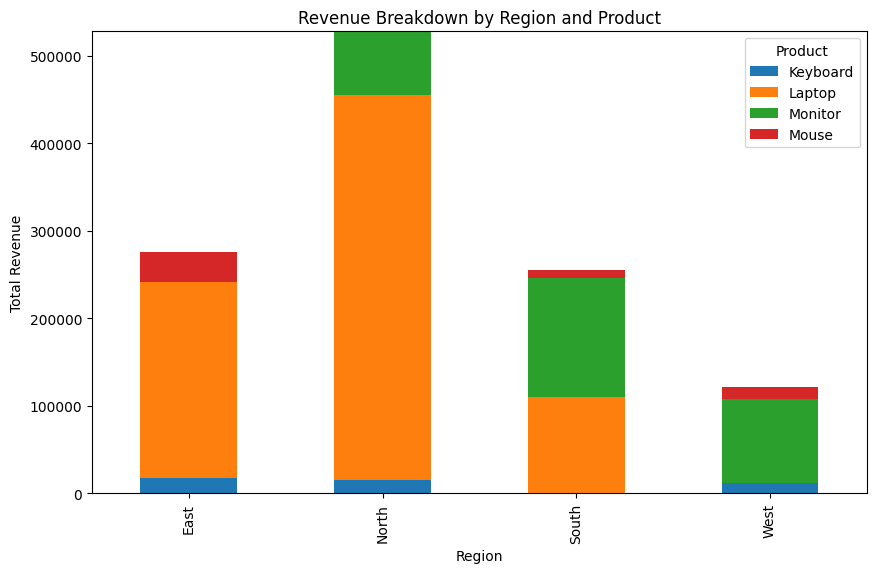

In [241]:
#Is any region heavily dependent on a single product?
# 1. Pivot the data and handle duplicates/missing combinations
pivot_df = df.pivot_table(
    index='Region', 
    columns='Product', 
    values='Revenue', 
    aggfunc='sum', 
    fill_value=0
)

# 2. Plot as a stacked bar plot
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6))

# 3. Add labels and title
ax.set_title('Revenue Breakdown by Region and Product')
ax.set_xlabel('Region')
ax.set_ylabel('Total Revenue')

In [242]:
df

,Date,Region,Product,Quantity,Unit_Price,Revenue
0,2025-01-05,North,Laptop,5,55000,275000
1,2025-01-07,South,Mouse,20,500,10000
2,2025-01-10,East,Keyboard,15,1200,18000
3,2025-01-12,West,Monitor,8,12000,96000
4,2025-01-15,North,Laptop,3,55000,165000
5,2025-01-18,South,Monitor,4,12000,48000
6,2025-01-20,East,Mouse,30,500,15000
7,2025-01-22,West,Keyboard,10,1200,12000
8,2025-01-25,North,Monitor,6,12000,72000
9,2025-01-28,South,Laptop,2,55000,110000


# Trend Analysis

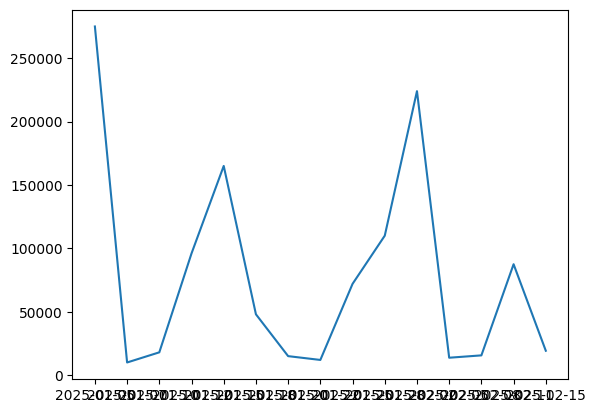

In [243]:
#How do sales change over time?
plt.plot(df['Date'],df['Revenue'])

In [310]:
#Which month generated more revenue?
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = pd.DataFrame(df.groupby(df['Date'].dt.to_period('M'))['Revenue'].sum())
monthly_sales.reset_index()

,Date,Revenue
0,2025-01,821000
1,2025-02,360100


Text(0, 0.5, 'Revenue')

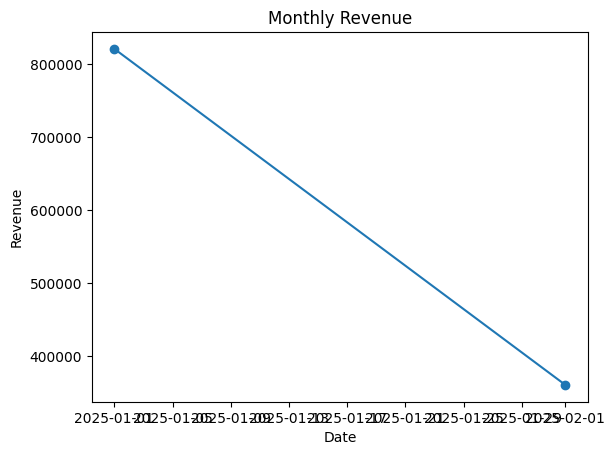

In [311]:
monthly_sales = monthly_sales.reset_index()
monthly_sales['Date'] = monthly_sales['Date'].dt.to_timestamp()
plt.plot(monthly_sales['Date'], monthly_sales['Revenue'], marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')

In [312]:
#Are sales increasing or decreasing?
print("Decreasing")

Decreasing


In [331]:
#Which date recorded the highest revenue?
df.loc[df['Revenue'].idxmax(), ['Date']]

Date   2025-01-05
Name: 0, dtype: datetime64[us]

In [332]:
#Which date recorded the lowest revenue?
df.loc[df['Revenue'].idxmin(), ['Date']]

Date   2025-01-07
Name: 1, dtype: datetime64[us]

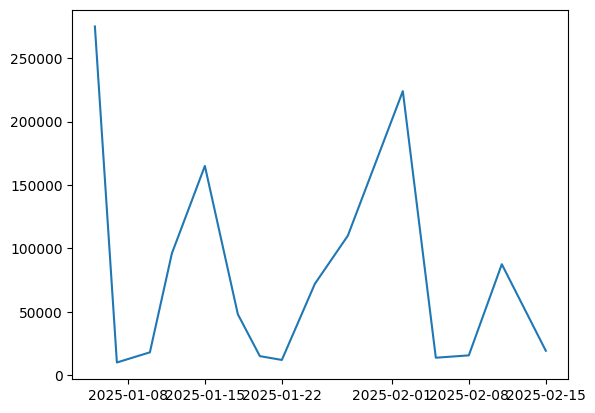

In [334]:
#Identify any unusual spikes in sales.
plt.plot(df['Date'], df['Revenue'])

# Revenue Analysis